1 binary in COMPAS represents 79.11015055714887  solar masses formed
20000000
1582203011.1429775  [Msun]
ClassCOMPAS: Remember to self.setCOMPASDCOmask()
                    then self.setCOMPASData()
          and optionally self.setGridAndMassEvolved() if using a metallicity grid


/Users/alexandermigala/Documents/Github/metallicity_mergers/population_vis.py:179: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  eff_ax.legend()
/Users/alexandermigala/Documents/Github/metallicity_mergers/population_vis.py:180: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  eff_fig.show()


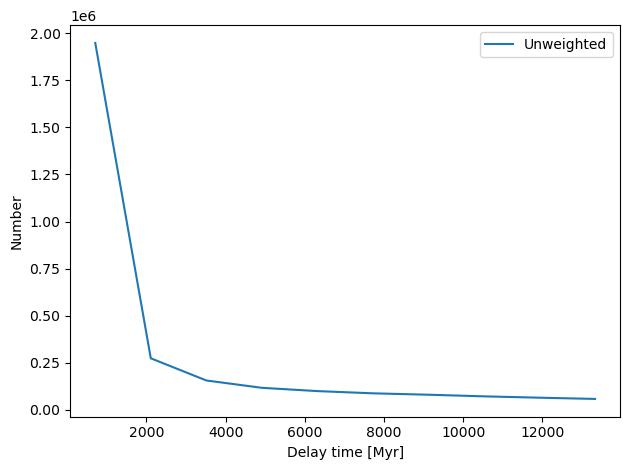

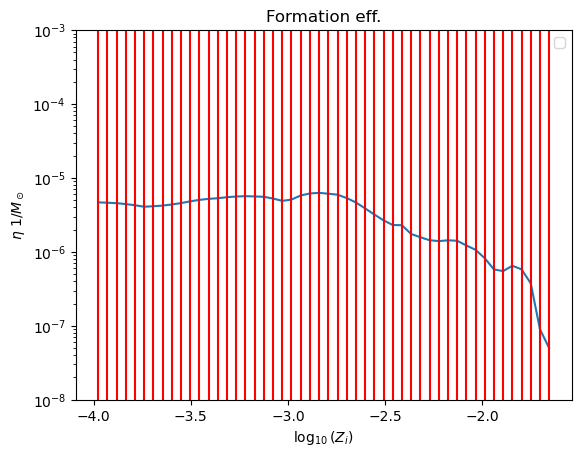

In [1]:
import numpy as np
from shared import networks, get_all_snr_weights, fci_plot_merger_rate_from_hdf_file
import h5py
from population_vis import get_formation_efficiency

fname = 'Boesky_alpha0.1beta0.5.h5'
filepath = f'/Volumes/Elements/{fname}'

# SET UP DATA -- from a basic dict, port to an h5 file and then store this into the output file
# now we want to use some real data
fdata = h5py.File(filepath)
all_dco_seeds = fdata['BSE_Double_Compact_Objects']['SEED'][()]
all_seeds = fdata['BSE_System_Parameters']['SEED'][()]
metallicities = fdata["BSE_System_Parameters"]["Metallicity@ZAMS(1)"][()]
# potentially mask with/without a stable mass transfer or without an envelope
mixture_weight = fdata["BSE_System_Parameters"]["mixture_weight"][()]
fdata.close()
TYPES = 'BBH'
fe_binned, fe_bins, compasdata = get_formation_efficiency(filepath, types=TYPES)
delayTimes = compasdata.delayTimes

# need to get the metallicities as well
dco_query = np.isin(all_seeds, all_dco_seeds[compasdata.DCOmask])
dco_metallicities = metallicities[dco_query]
dco_mixture_weight = mixture_weight[dco_query]
assert len(delayTimes[()]) == len(dco_metallicities), "Something went wrong with masking for dco metallicities"
det_choice = 'O5'

In [ ]:
# now export basic data for use in commputing the SNRs. want to get the redshift bins and the masses of the systems
# getting the masses will be slightly different
fdata = h5py.File(filepath) # have to reopen this file
dco_mass1 = fdata['BSE_Double_Compact_Objects']['Mass(1)'][compasdata.DCOmask]
# print(dco_mass1.shape)
dco_mass2 = fdata['BSE_Double_Compact_Objects']['Mass(2)'][compasdata.DCOmask]
# assert fiducial_plotting_data['all_weights'].shape[0] == dco_mass1.shape[0], "Did not mask DCOs correctly.."
# fdata.close()

# now we can push this off to a file to get the SNR weight in that redshift bin
# we want the redshift bins from the rate combined
all_dcomasses = np.vstack((dco_mass1, dco_mass2)) # top row is mass1
print(all_dcomasses.shape)

np.save(f'{fname}_{TYPES}_masses.npy', all_dcomasses)

reds_from_fci = fdata['Rates_comb']['redshifts']

assert len(compasdata.DCOmask) == len(fdata['Rates_comb']['DCOmask'][()]), "FCI DCO mask is not current"
np.save('redshift_bins_of_interest.npy', fdata['Rates_comb']['redshifts'])

# do reload check
# assert np.load(f'Boesky_sims_{TYPES}_masses.npy').shape == all_dcomasses.shape, "DCO masses did not save correctly"
# assert np.load('redshift_bins_of_interest.npy').shape == fiducial_plotting_data['redshifts'].shape, "Redshifts did not save correctly"

(2, 2958397)
<KeysViewHDF5 ['BSE_Common_Envelopes', 'BSE_Double_Compact_Objects', 'BSE_RLOF', 'BSE_Supernovae', 'BSE_System_Parameters', 'Rates_comb', 'Rates_mu00.025_muz-0.052_alpha-1.88_sigma01.15_sigmaz0.0477_BBH_0.1_10.0', 'Run_Details']>
[0 0 0 ... 0 0 0]


In [16]:
# run many
for dets in ['O5', 'ET_CE']:
    all_snr_weights = get_all_snr_weights(
        networks[dets]['array'],
        networks[dets]['snr'],
        dco_metallicities,
    TYPES
    )
    np.save(f'{TYPES}_{dets}_{networks[dets]['snr']}.npy', all_snr_weights)

Z bins: 0it [00:00, ?it/s]

ValueError: could not broadcast input array from shape (5448354,) into shape (2958397,)

In [ ]:
# run single
all_snr_weights = get_all_snr_weights(
    networks[det_choice]['array'],
    networks[det_choice]['snr'],
    dco_metallicities,
    TYPES
)
np.save(f'{TYPES}_{det_choice}_{networks[det_choice]['snr']}.npy', all_snr_weights)

## Save the fiducial plotting code for use in a large plot

In [3]:
import pickle
PLOT_Z_LOG = True
Zm = np.log10(dco_metallicities/0.012) if PLOT_Z_LOG else dco_metallicities/0.012
# rates_key = f'Rates_mu00.025_muz-0.052_alpha-1.88_sigma01.15_sigmaz0.0477_{TYPES}'
rates_key = 'Rates_comb'

import shared
import importlib
importlib.reload(shared)

plotting_data = shared.fci_plot_merger_rate_from_hdf_file(
    filepath,
    rates_key,
    dco_metallicities
    )
plotting_data['Zm'] = Zm
plotting_data['types'] = TYPES

with open(f'intrinsic_plotting_data_{TYPES}.pkl', 'wb') as p:
    pickle.dump(plotting_data, p)

38


In [20]:
for k in plotting_data.keys():
    print(type(plotting_data[k]))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'str'>
